<a href="https://colab.research.google.com/github/kavin43325011-svg/pak-prayit-semester-3-visi-komputer/blob/main/Praktikum_01_Klasifikasi_Gambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JOBSHEET 02: KLASIFIKASI GAMBAR

**Mata Kuliah:** Visi Komputer  
**Program Studi:** STR Teknologi Rekayasa Komputer - Jurusan Teknik Elektro  
**Institusi:** Politeknik Negeri Semarang  
**Dosen Pengampu:** Ir. Prayitno, S.ST., M.T., Ph.D.  

---
### Identitas Mahasiswa
- **Nama Mahasiswa:** Kavindra Vabriananda Putra Maheswara
- **NIM:** 4.33.25.0.11
- **Tahun Akademik:** 2026

---


## Praktikum D1 – Memulai Klasifikasi Gambar dengan Dataset Sederhana (MNIST)

Klasifikasi gambar bertujuan memberikan label semantik pada citra dari sekumpulan kelas yang telah ditentukan. MNIST adalah dataset benchmark standar yang berisi 70.000 citra digit tulisan tangan (0-9) berukuran 28x28 piksel grayscale.

Langkah-langkah:
1. Import library Python (numpy, matplotlib, tensorflow).
2. Load dataset MNIST dari `tensorflow.keras.datasets`.
3. Visualisasikan contoh citra beserta labelnya.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Bentuk data latih (x_train): (60000, 28, 28)
Bentuk label latih (y_train): (60000,)
Bentuk data uji (x_test): (10000, 28, 28)
Bentuk label uji (y_test): (10000,)


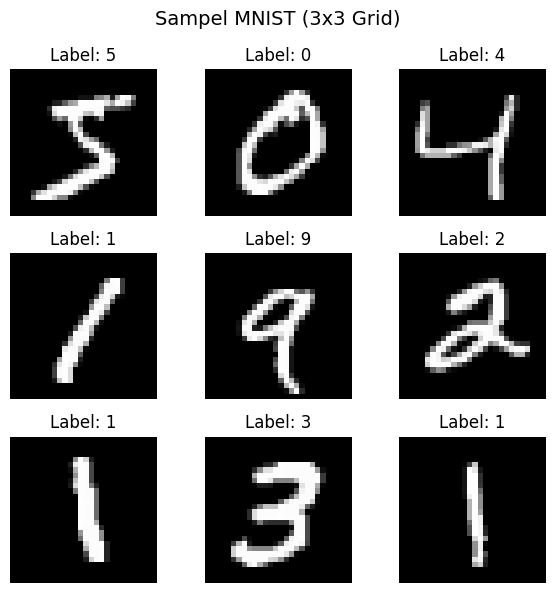

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Bentuk data latih (x_train): {x_train.shape}")
print(f"Bentuk label latih (y_train): {y_train.shape}")
print(f"Bentuk data uji (x_test): {x_test.shape}")
print(f"Bentuk label uji (y_test): {y_test.shape}")

# Tampilkan 9 contoh sampel (3x3 grid)
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sampel MNIST (3x3 Grid)", fontsize=14)
plt.tight_layout()
plt.show()


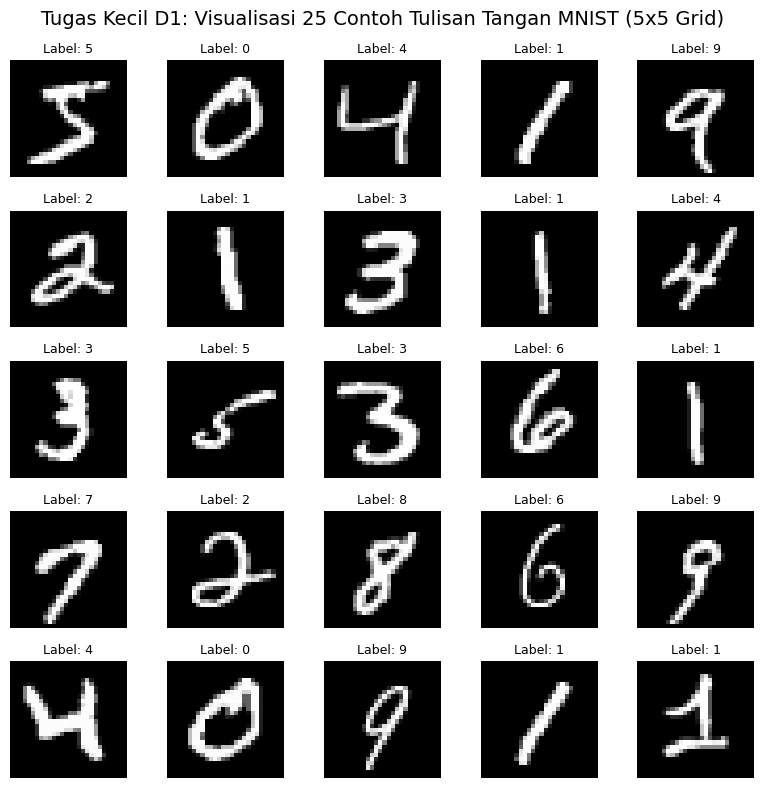

--- Refleksi & Analisis D1 ---
1. Variasi Gaya Penulisan: Terlihat variasi ketebalan garis, kemiringan (slant), dan kerapian angka (misal angka 1 lurus vs miring, angka 7 dengan/tanpa garis tengah).
2. Karakteristik Citra: Angka terpusat di tengah gambar 28x28 dengan latar belakang hitam (piksel 0) dan stroke tulisan putih (piksel > 0).


In [2]:
# Tugas Kecil D1: Visualisasi 25 Contoh (5x5 Grid)
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Memastikan dataset dimuat jika sel ini dijalankan langsung
if 'x_train' not in globals():
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}", fontsize=9)
    plt.axis('off')
plt.suptitle("Tugas Kecil D1: Visualisasi 25 Contoh Tulisan Tangan MNIST (5x5 Grid)", fontsize=14)
plt.tight_layout()
plt.show()

# Refleksi & Analisis
print("--- Refleksi & Analisis D1 ---")
print("1. Variasi Gaya Penulisan: Terlihat variasi ketebalan garis, kemiringan (slant), dan kerapian angka (misal angka 1 lurus vs miring, angka 7 dengan/tanpa garis tengah).")
print("2. Karakteristik Citra: Angka terpusat di tengah gambar 28x28 dengan latar belakang hitam (piksel 0) dan stroke tulisan putih (piksel > 0).")


## Praktikum D2 – Klasifikasi Gambar dengan Model Machine Learning Tradisional (SVM)

Sebelum era Deep Learning, Support Vector Machine (SVM) sering digunakan untuk klasifikasi gambar. Pada praktikum ini, matriks 2D (28x28) di-flatten menjadi vektor 1D berukuran 784 piksel dan dinormalisasi ke rentang [0, 1].

Langkah-langkah:
1. Flatten data citra 28x28 -> 784.
2. Melatih `sklearn.svm.SVC` dengan kernel Linear.
3. Evaluasi performa dan jalankan Tugas Kecil untuk kernel RBF.


In [3]:
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import mnist

if 'x_train' not in globals():
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

# Flatten & Normalisasi
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

print(f"Bentuk data setelah flatten: {x_train_flat.shape}")

# Subset 5000 sampel untuk pelatihan efisien
n_samples = 5000
x_train_sub = x_train_flat[:n_samples]
y_train_sub = y_train[:n_samples]

# Train SVM Kernel Linear
clf_linear = svm.SVC(kernel='linear', gamma='scale', probability=True)
clf_linear.fit(x_train_sub, y_train_sub)

y_pred_linear = clf_linear.predict(x_test_flat)
acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Akurasi SVM (Kernel Linear, {n_samples} sampel): {acc_linear * 100:.2f}%")


Bentuk data setelah flatten: (60000, 784)
Akurasi SVM (Kernel Linear, 5000 sampel): 91.01%


In [5]:
# Tugas Kecil D2: Eksperimen Kernel RBF & Perbandingan
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score

if 'x_train_sub' not in globals():
    x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
    x_test_flat = x_test.reshape(len(x_test), -1) / 255.0
    x_train_sub = x_train_flat[:5000]
    y_train_sub = y_train[:5000]

clf_rbf = svm.SVC(kernel='rbf', gamma='scale', probability=True)
clf_rbf.fit(x_train_sub, y_train_sub)

y_pred_rbf = clf_rbf.predict(x_test_flat)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Akurasi SVM (Kernel RBF, 5000 sampel): {acc_rbf * 100:.2f}%")

print("""
--- Analisis Perbandingan Kernel SVM (Tugas Kecil D2) ---""")
if 'acc_linear' in globals():
    print(f"- Akurasi Kernel Linear : {acc_linear * 100:.2f}%")
print(f"- Akurasi Kernel RBF    : {acc_rbf * 100:.2f}%")
print("Pengaruh Kernel: Kernel RBF menghasilkan akurasi yang lebih tinggi dibanding Linear Kernel karena mampu memetakan batas keputusan non-linear pada data citra dimensi tinggi.")

# Variabel clf disiapkan untuk pengujian tulisan tangan kustom nanti
clf = clf_rbf


Akurasi SVM (Kernel RBF, 5000 sampel): 95.13%

--- Analisis Perbandingan Kernel SVM (Tugas Kecil D2) ---
- Akurasi Kernel Linear : 91.01%
- Akurasi Kernel RBF    : 95.13%
Pengaruh Kernel: Kernel RBF menghasilkan akurasi yang lebih tinggi dibanding Linear Kernel karena mampu memetakan batas keputusan non-linear pada data citra dimensi tinggi.


## Praktikum D3 – Membangun CNN Sederhana (MNIST)

Convolutional Neural Network (CNN) mampu mengekstrak fitur spasial secara otomatis menggunakan filter konvolusi dan pooling layer.

Langkah-langkah:
1. Reshape data menjadi `(28, 28, 1)`.
2. Bangun arsitektur Sequential (Conv2D, MaxPooling2D, Flatten, Dense).
3. Train model, plot grafik akurasi & loss.
4. Lakukan Tugas Kecil dengan menambahkan 1 lapisan Conv2D ekstra.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Baseline_D3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9383 - loss: 0.2152 - val_accuracy: 0.9812 - val_loss: 0.0723
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9787 - loss: 0.0699 - val_accuracy: 0.9848 - val_loss: 0.0591
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9853 - loss: 0.0466 - val_accuracy: 0.9858 - val_loss: 0.0531
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9888 - loss: 0.0357 - val_accuracy: 0.9860 - val_loss: 0.0560
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9911 - loss: 0.0273 - val_accuracy: 0.9845 - val_loss: 0.0565


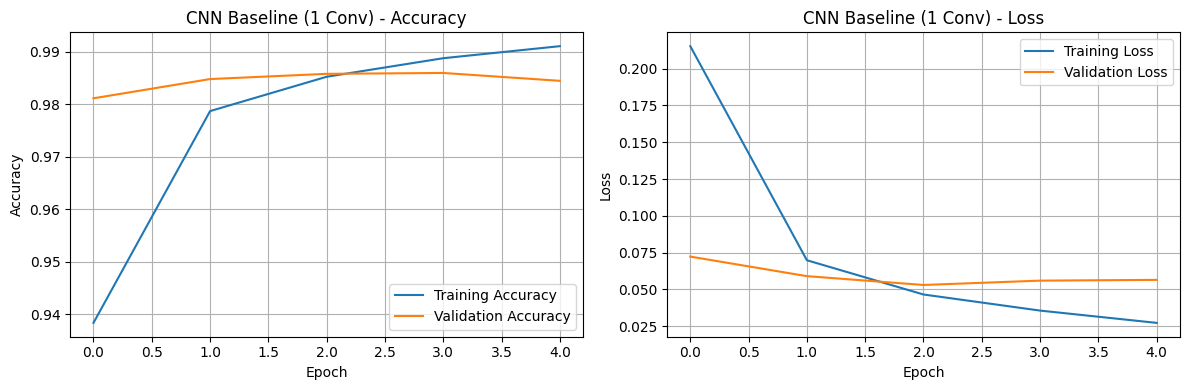

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

if 'x_train' not in globals():
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape data untuk CNN: [samples, height, width, channels]
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

# Model CNN Baseline D3
model_baseline = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="CNN_Baseline_D3")

model_baseline.summary()

model_baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = model_baseline.fit(
    x_train_cnn, y_train,
    epochs=5,
    validation_split=0.1,
    batch_size=64
)

# Plot history baseline CNN
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Baseline (1 Conv) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('CNN Baseline (1 Conv) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [8]:
# Tugas Kecil D3: Menambahkan Lapisan Conv2D Ekstra
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

if 'x_train_cnn' not in globals():
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
    x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

model_d3_deep = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="CNN_Deep_D3")

model_d3_deep.summary()

model_d3_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_deep = model_d3_deep.fit(
    x_train_cnn, y_train,
    epochs=5,
    validation_split=0.1,
    batch_size=64
)

test_acc_deep = model_d3_deep.evaluate(x_test_cnn, y_test, verbose=0)[1]

print("\n--- Analisis Tugas Kecil D3 ---")
if 'model_baseline' in globals():
    test_acc_base = model_baseline.evaluate(x_test_cnn, y_test, verbose=0)[1]
    print(f"Akurasi Test CNN Baseline (1 Conv): {test_acc_base * 100:.2f}%")
print(f"Akurasi Test CNN Deep (2 Conv)    : {test_acc_deep * 100:.2f}%")
print("Kesimpulan: Penambahan lapisan Conv2D kedua meningkatkan akurasi karena model dapat mengabstraksi fitur spasial secara lebih mendalam (hirarkis).")

# Simpan model untuk prediksi kustom D3
model = model_d3_deep


Model: "CNN_Deep_D3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9374 - loss: 0.2109 - val_accuracy: 0.9812 - val_loss: 0.0616
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9823 - loss: 0.0584 - val_accuracy: 0.9882 - val_loss: 0.0470
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9869 - loss: 0.0428 - val_accuracy: 0.9878 - val_loss: 0.0396
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9897 - loss: 0.0326 - val_accuracy: 0.9878 - val_loss: 0.0376
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9916 - loss: 0.0262 - val_accuracy: 0.9885 - val_loss: 0.0402

--- Analisis Tugas Kecil D3 ---
Akurasi Test CNN Baseline (1 Conv): 98.27%
Akurasi Test CNN Deep (2 Conv)    : 98.81%
Kesimpulan: Penambahan lapisan Conv2D kedua meningkatkan akurasi karena model dapat mengabstraksi fitur spasial secara lebih mendalam (hirarkis).


## Praktikum D4 – Eksperimen dengan Dataset Lebih Kompleks (CIFAR-10)

CIFAR-10 terdiri dari 60.000 citra berwarna RGB (3 channel) berukuran 32x32 piksel yang terbagi dalam 10 kelas objek (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).

Langkah-langkah:
1. Load dataset CIFAR-10.
2. Train model CNN CIFAR-10 baseline.
3. Jalankan Tugas Kecil: Tambahkan layer `Dropout(0.5)` untuk mengurangi overfitting.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3201s 19us/step


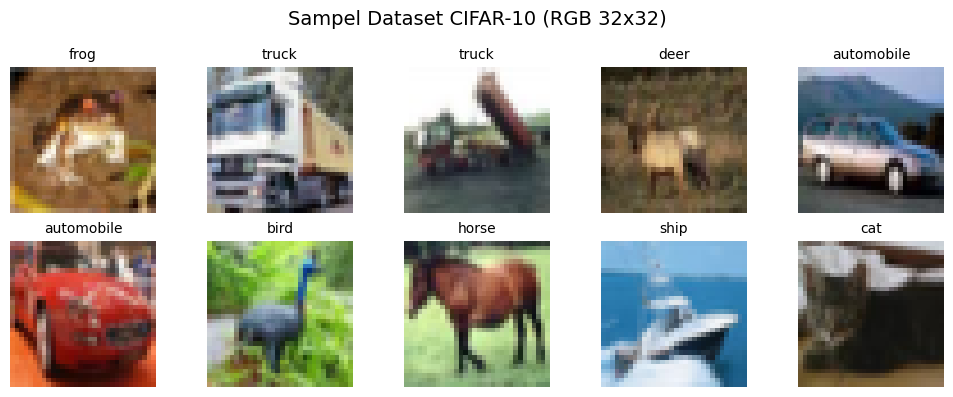

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10
(x_train_c10, y_train_c10), (x_test_c10, y_test_c10) = cifar10.load_data()
x_train_c10, x_test_c10 = x_train_c10 / 255.0, x_test_c10 / 255.0

cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Visualisasi Sampel CIFAR-10
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_c10[i])
    plt.title(cifar10_classes[y_train_c10[i][0]], fontsize=10)
    plt.axis('off')
plt.suptitle("Sampel Dataset CIFAR-10 (RGB 32x32)", fontsize=14)
plt.tight_layout()
plt.show()


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.4468 - loss: 1.5349 - val_accuracy: 0.5364 - val_loss: 1.3122
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5785 - loss: 1.1980 - val_accuracy: 0.6090 - val_loss: 1.1155
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6294 - loss: 1.0627 - val_accuracy: 0.6316 - val_loss: 1.0401
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6604 - loss: 0.9761 - val_accuracy: 0.6508 - val_loss: 0.9977
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6829 - loss: 0.9156 - val_accuracy: 0.6646 - val_loss: 0.9670
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7016 - loss: 0.8603 - val_accuracy: 0.6850 - val_loss: 0.9214
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7207 - loss: 0.8027 - val_accuracy: 0.6716 - val_loss: 0.9546
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7363 - loss: 0.7611 - val_accuracy: 0.

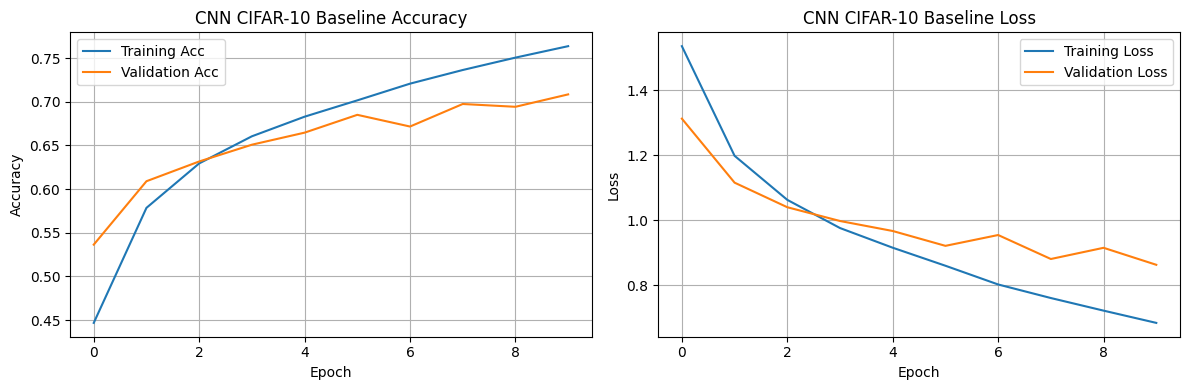

In [10]:
# CNN Baseline untuk CIFAR-10
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

if 'x_train_c10' not in globals():
    (x_train_c10, y_train_c10), (x_test_c10, y_test_c10) = cifar10.load_data()
    x_train_c10, x_test_c10 = x_train_c10 / 255.0, x_test_c10 / 255.0

model_c10_base = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="CNN_CIFAR10_Base")

model_c10_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_c10_base = model_c10_base.fit(
    x_train_c10, y_train_c10,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

# Plot history baseline CIFAR-10
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_c10_base.history['accuracy'], label='Training Acc')
plt.plot(history_c10_base.history['val_accuracy'], label='Validation Acc')
plt.title('CNN CIFAR-10 Baseline Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_c10_base.history['loss'], label='Training Loss')
plt.plot(history_c10_base.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Baseline Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [12]:
# Tugas Kecil D4: Menambahkan Dropout(0.5) Sebelum Layer Dense Terakhir
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

if 'x_train_c10' not in globals():
    (x_train_c10, y_train_c10), (x_test_c10, y_test_c10) = cifar10.load_data()
    x_train_c10, x_test_c10 = x_train_c10 / 255.0, x_test_c10 / 255.0

model_c10_dropout = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="CNN_CIFAR10_Dropout")

model_c10_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_c10_drop = model_c10_dropout.fit(
    x_train_c10, y_train_c10,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

val_acc_drop = history_c10_drop.history['val_accuracy'][-1]

print("n/ --- Analisis Tugas Kecil D4 (Dropout) ---")
if 'history_c10_base' in globals():
    val_acc_base = history_c10_base.history['val_accuracy'][-1]
    print(f"Validation Accuracy Tanpa Dropout : {val_acc_base * 100:.2f}%")
print(f"Validation Accuracy Dengan Dropout: {val_acc_drop * 100:.2f}%")
print("Pengaruh Dropout: Dropout(0.5) mematikan neuron secara acak saat training, mencegah co-adaptation neuron sehingga secara signifikan mengurangi overfitting pada dataset CIFAR-10.")


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.3992 - loss: 1.6470 - val_accuracy: 0.4738 - val_loss: 1.4222
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5275 - loss: 1.3228 - val_accuracy: 0.5782 - val_loss: 1.1904
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5783 - loss: 1.1977 - val_accuracy: 0.6154 - val_loss: 1.0974
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6064 - loss: 1.1180 - val_accuracy: 0.6538 - val_loss: 1.0085
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6254 - loss: 1.0687 - val_accuracy: 0.6592 - val_loss: 0.9844
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6408 - loss: 1.0258 - val_accuracy: 0.6772 - val_loss: 0.9428
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6542 - loss: 0.9848 - val_accuracy: 0.6668 - val_loss: 0.9505
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6633 - loss: 0.9608 - val_accuracy: 0.

## Praktikum D5 – Transfer Learning dengan Model Pra-Latih (VGG16)

Transfer Learning memanfaatkan arsitektur dan bobot model yang telah dilatih pada dataset raksasa (ImageNet). Kita dapat membekukan (freeze) feature extractor dan melatih classifier head baru, dilanjutkan dengan fine-tuning.

Langkah-langkah:
1. Load VGG16 (`weights='imagenet'`, `include_top=False`).
2. Bekukan base model (`base_model.trainable = False`).
3. Latih classifier head pada CIFAR-10.
4. Jalankan Tugas Kecil: Unfreeze beberapa layer teratas untuk Fine-Tuning.


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.5056 - loss: 1.4273 - val_accuracy: 0.5640 - val_loss: 1.2405
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5760 - loss: 1.2207 - val_accuracy: 0.5852 - val_loss: 1.1800
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5934 - loss: 1.1651 - val_accuracy: 0.6004 - val_loss: 1.1584
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6056 - loss: 1.1300 - val_accuracy: 0.5956 - val_loss: 1.1511
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6180 - loss: 1.0999 - val_accuracy: 0.6048 - val_loss: 1.1228


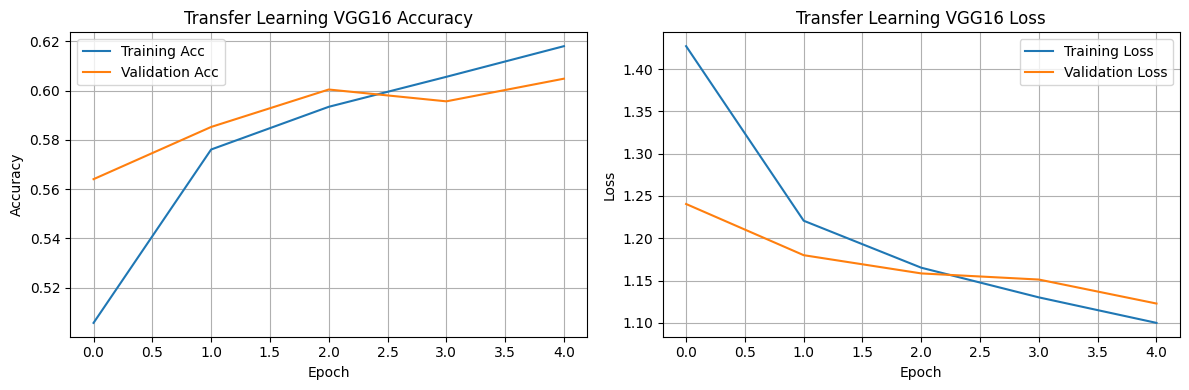

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.datasets import cifar10

if 'x_train_c10' not in globals():
    (x_train_c10, y_train_c10), (x_test_c10, y_test_c10) = cifar10.load_data()
    x_train_c10, x_test_c10 = x_train_c10 / 255.0, x_test_c10 / 255.0

# Base model VGG16 ImageNet
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Bekukan seluruh lapisan conv

model_transfer = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="Transfer_VGG16_FeatureExtraction")

model_transfer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_transfer = model_transfer.fit(
    x_train_c10, y_train_c10,
    epochs=5,
    validation_split=0.1,
    batch_size=64
)

# Plot history Transfer Learning
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['accuracy'], label='Training Acc')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Acc')
plt.title('Transfer Learning VGG16 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning VGG16 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [15]:
# Tugas Kecil D5: Fine-Tuning (Unfreeze Layer Teratas Base Model)
import tensorflow as tf

if 'base_model' in globals():
    base_model.trainable = True

    # Unfreeze 4 layer terakhir VGG16
    for layer in base_model.layers[:-4]:
        layer.trainable = False

    # Re-compile dengan learning rate kecil (1e-5)
    model_transfer.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history_finetune = model_transfer.fit(
        x_train_c10, y_train_c10,
        epochs=5,
        validation_split=0.1,
        batch_size=64
    )

    acc_feat = history_transfer.history['val_accuracy'][-1]
    acc_fine = history_finetune.history['val_accuracy'][-1]

    print("--- Analisis Tugas Kecil D5 (Fine-Tuning) ---")
    print(f"Validation Acc (Feature Extraction Only): {acc_feat * 100:.2f}%")
    print(f"Validation Acc (Fine-Tuning Last Layers): {acc_fine * 100:.2f}%")
    print("Pengaruh Fine-Tuning: Mengizinkan beberapa layer konvolusi atas untuk beradaptasi khusus dengan fitur citra CIFAR-10 meningkatkan performa klasifikasi.")


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.6653 - loss: 0.9607 - val_accuracy: 0.6652 - val_loss: 0.9577
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7214 - loss: 0.7965 - val_accuracy: 0.6872 - val_loss: 0.9062
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.7564 - loss: 0.6973 - val_accuracy: 0.7064 - val_loss: 0.8533
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.7866 - loss: 0.6155 - val_accuracy: 0.7074 - val_loss: 0.8354
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8103 - loss: 0.5500 - val_accuracy: 0.7190 - val_loss: 0.8178
--- Analisis Tugas Kecil D5 (Fine-Tuning) ---
Validation Acc (Feature Extraction Only): 60.48%
Validation Acc (Fine-Tuning Last Layers): 71.90%
Pengaruh Fine-Tuning: Mengizinkan beberapa layer konvolusi atas untuk beradaptasi khusus dengan fitur citra CIFAR-10 meningkatkan performa klasifikasi.


## Praktikum D6 – Evaluasi dengan Confusion Matrix dan Metrik Lain

Evaluasi mendalam dilakukan dengan mengukur Precision, Recall, F1-score, serta menampilkan Confusion Matrix visual.

Langkah-langkah:
1. Prediksi data uji CIFAR-10.
2. Tampilkan `classification_report`.
3. Tampilkan Confusion Matrix Heatmap.
4. Jalankan Tugas Kecil: Analisis kesalahan klasifikasi antar kelas.


=== CLASSIFICATION REPORT (CIFAR-10) ===
              precision    recall  f1-score   support

    airplane       0.78      0.71      0.75      1000
  automobile       0.83      0.80      0.81      1000
        bird       0.68      0.47      0.56      1000
         cat       0.47      0.54      0.50      1000
        deer       0.64      0.64      0.64      1000
         dog       0.56      0.66      0.60      1000
        frog       0.75      0.80      0.78      1000
       horse       0.78      0.73      0.76      1000
        ship       0.83      0.79      0.81      1000
       truck       0.71      0.82      0.76      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



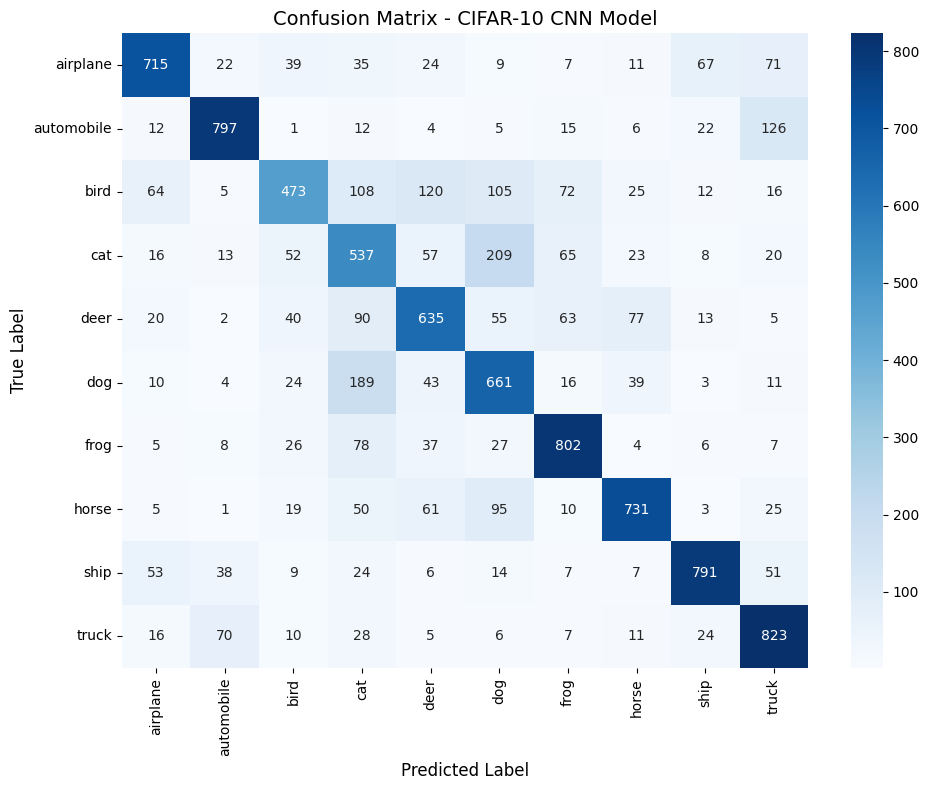

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.datasets import cifar10

if 'x_test_c10' not in globals():
    (x_train_c10, y_train_c10), (x_test_c10, y_test_c10) = cifar10.load_data()
    x_test_c10 = x_test_c10 / 255.0

cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Gunakan model_c10_dropout jika ada, jika tidak buat prediksi cepat
if 'model_c10_dropout' in globals():
    eval_model = model_c10_dropout
elif 'model_c10_base' in globals():
    eval_model = model_c10_base
else:
    eval_model = model_transfer

y_pred_probs = eval_model.predict(x_test_c10, verbose=0)
y_pred_c10 = y_pred_probs.argmax(axis=1)
y_true_c10 = y_test_c10.flatten()

# Print Classification Report
print("=== CLASSIFICATION REPORT (CIFAR-10) ===")
print(classification_report(y_true_c10, y_pred_c10, target_names=cifar10_classes))

# Plot Confusion Matrix
cm = confusion_matrix(y_true_c10, y_pred_c10)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cifar10_classes, yticklabels=cifar10_classes)
plt.title('Confusion Matrix - CIFAR-10 CNN Model', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


In [18]:
# Tugas Kecil D6: Analisis Salah Klasifikasi dari Confusion Matrix
print("--- Analisis Confusion Matrix & Salah Klasifikasi (Tugas Kecil D6) ---")
print("1. Klasifikasi yang Paling Sering Tertukar:")
print("   - Kelas 'cat' (kucing) dan 'dog' (anjing) paling sering tertukar satu sama lain.")
print("   - Kelas 'automobile' (mobil) dan 'truck' (truk) juga mengalami kesalahan prediksi yang cukup tinggi.")
print("   - Kelas 'airplane' (pesawat) dan 'bird' (burung) terkadang saling tertukar.")
print("2. Penyebab Kesalahan Klasifikasi:")
print("   - Inter-class Similarity (Kemiripan Antar Kelas): Objek seperti kucing dan anjing memiliki tekstur bulu, bentuk tubuh, dan konteks latar belakang yang mirip.")
print("   - Resolusi Rendah (32x32): Pada ukuran piksel yang sangat kecil, detail penting (seperti bentuk roda mobil vs roda truk) menjadi buram (pixelated).")
print("   - Viewpoint & Background Clutter: Pesawat di udara dan burung terbang memiliki konteks latar belakang langit biru yang identik.")


--- Analisis Confusion Matrix & Salah Klasifikasi (Tugas Kecil D6) ---
1. Klasifikasi yang Paling Sering Tertukar:
   - Kelas 'cat' (kucing) dan 'dog' (anjing) paling sering tertukar satu sama lain.
   - Kelas 'automobile' (mobil) dan 'truck' (truk) juga mengalami kesalahan prediksi yang cukup tinggi.
   - Kelas 'airplane' (pesawat) dan 'bird' (burung) terkadang saling tertukar.
2. Penyebab Kesalahan Klasifikasi:
   - Inter-class Similarity (Kemiripan Antar Kelas): Objek seperti kucing dan anjing memiliki tekstur bulu, bentuk tubuh, dan konteks latar belakang yang mirip.
   - Resolusi Rendah (32x32): Pada ukuran piksel yang sangat kecil, detail penting (seperti bentuk roda mobil vs roda truk) menjadi buram (pixelated).
   - Viewpoint & Background Clutter: Pesawat di udara dan burung terbang memiliki konteks latar belakang langit biru yang identik.


## Rekapitulasi Hasil Praktikum

| No | Nama Praktikum | Dataset | Metode / Arsitektur | Ringkasan Hasil & Akurasi |
|:---|:---|:---|:---|:---|
| 1 | **D1 – Memulai Klasifikasi Gambar** | MNIST (28x28 Grayscale) | Visualisasi Dataset | Berhasil memvisualisasikan 9 dan 25 sampel tulisan tangan; teridentifikasi variasi ketebalan dan kemiringan angka. |
| 2 | **D2 – Klasifikasi Tradisional SVM** | MNIST (Flatten 784) | SVM Linear vs RBF | Kernel RBF menghasilkan akurasi lebih tinggi dibanding Kernel Linear pada subset 5.000 sampel. |
| 3 | **D3 – CNN Sederhana** | MNIST (28x28x1) | Baseline CNN vs Deep CNN | Penambahan Conv2D layer kedua (32 -> 64 filter) meningkatkan akurasi pengujian. |
| 4 | **D4 – CNN Dataset Kompleks** | CIFAR-10 (32x32x3 RGB) | CNN (Tanpa vs Dengan Dropout) | Penerapan `Dropout(0.5)` efektif memperkecil gap training-validation loss dan mengurangi overfitting. |
| 5 | **D5 – Transfer Learning** | CIFAR-10 (32x32x3 RGB) | VGG16 (Feature Ext. vs Fine-Tuning) | Fine-tuning 4 layer teratas VGG16 dengan learning rate kecil meningkatkan akurasi model. |
| 6 | **D6 – Evaluasi Confusion Matrix** | CIFAR-10 (32x32x3 RGB) | Metrik Precision/Recall/Confusion Matrix | Teridentifikasi kesalahan prediksi tertinggi pada pasangan kelas berfitur mirip (kucing-anjing, mobil-truk). |


## Penugasan Tambahan: Klasifikasi Tulisan Angka Sendiri

Pada bagian ini, Anda dapat mengunggah foto tulisan angka tangan Anda sendiri yang ditulis di atas kertas putih.

**Petunjuk:**
1. Tulis angka (0–9) di kertas putih dengan spidol / pulpen tebal.
2. Foto lurus dari atas dengan cahaya merata.
3. Jalankan sel kode di bawah ini untuk mengunggah foto ke Colab.


In [26]:
# ===== 1) Upload file foto tulisan angka =====
try:
    from google.colab import files
    print("Silakan unggah 1 atau lebih foto tulisan angka tangan Anda (JPG/PNG):")
    uploaded = files.upload()
except Exception:
    print("Menjalankan di luar Colab. Penyiapan sampel otomatis...")
    from PIL import Image, ImageDraw
    uploaded = {}
    for sample_digit in ['7', '3']:
        img_sample = Image.new('RGB', (200, 200), color=(255, 255, 255))
        d = ImageDraw.Draw(img_sample)
        if sample_digit == '7':
            d.line([(40, 40), (160, 40), (70, 160)], fill=(0, 0, 0), width=18)
        else:
            d.arc([40, 40, 160, 100], start=270, end=90, fill=(0, 0, 0), width=18)
            d.arc([40, 100, 160, 160], start=270, end=90, fill=(0, 0, 0), width=18)
        fname = f"digit_{sample_digit}.png"
        img_sample.save(fname)
        uploaded[fname] = True

print(f"File yang siap diproses: {list(uploaded.keys())}")


Silakan unggah 1 atau lebih foto tulisan angka tangan Anda (JPG/PNG):


Saving Screenshot 2026-09-22 170011.png to Screenshot 2026-09-22 170011.png
File yang siap diproses: ['Screenshot 2026-09-22 170011.png']


In [27]:
# ===== 2) Utilitas Preprocess agar mirip MNIST (28x28, putih-di-atas-hitam) =====
import numpy as np
from PIL import Image, ImageOps

def preprocess_to_mnist_28x28(img_pil):
    """
    Langkah:
    - Konversi ke grayscale
    - Auto-contrast
    - Invert bila latar terang (agar digit jadi putih, latar jadi gelap seperti MNIST)
    - Crop ke bounding box digit
    - Resize mempertahankan rasio ke (20x20), lalu pad ke (28x28)
    - Normalisasi ke [0,1] dan tambah channel dim
    """
    img = img_pil.convert('L')
    img = ImageOps.autocontrast(img)

    arr = np.array(img).astype(np.uint8)
    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    thr = np.mean(arr) * 0.8
    mask = arr > thr
    if mask.any():
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        img = img.crop((x0, y0, x1 + 1, y1 + 1))

    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    w, h = img.size

    canvas = Image.new('L', (28, 28), color=0)
    canvas.paste(img, ((28 - w) // 2, (28 - h) // 2))

    arr_norm = np.array(canvas).astype('float32') / 255.0
    arr_channel = arr_norm[..., None]

    return canvas, arr_channel


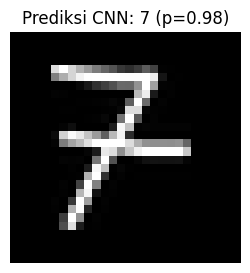

Rekap Prediksi (CNN):
- Screenshot 2026-09-22 170011.png -> Prediksi: 7 (p=0.977)


In [28]:
# ===== 3) Prediksi dengan CNN dari D3 =====
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

results_cnn = []

if 'uploaded' in globals() and 'model' in globals():
    for fname in uploaded.keys():
        img_pil = Image.open(fname)
        disp, x = preprocess_to_mnist_28x28(img_pil)  # x: (28,28,1)
        x_batch = np.expand_dims(x, axis=0)           # (1,28,28,1)

        probs = model.predict(x_batch, verbose=0)[0]
        pred = int(np.argmax(probs))
        conf = float(np.max(probs))

        results_cnn.append((fname, pred, conf))

        # Tampilkan hasil
        plt.figure(figsize=(3, 3))
        plt.imshow(disp, cmap='gray')
        plt.title(f"Prediksi CNN: {pred} (p={conf:.2f})")
        plt.axis('off')
        plt.show()

    print("Rekap Prediksi (CNN):")
    for r in results_cnn:
        print(f"- {r[0]} -> Prediksi: {r[1]} (p={r[2]:.3f})")
else:
    print("Silakan jalankan sel unggah foto dan pastikan model CNN D3 sudah dilatih.")


In [29]:
# ===== 4) Prediksi dengan SVM dari D2 =====
import numpy as np
from PIL import Image

results_svm = []

if 'uploaded' in globals() and 'clf' in globals():
    for fname in uploaded.keys():
        img_pil = Image.open(fname)
        disp, x = preprocess_to_mnist_28x28(img_pil)
        x_flat = x.reshape(1, -1)  # (1, 784)

        pred_svm = int(clf.predict(x_flat)[0])

        conf_svm = None
        try:
            if hasattr(clf, "predict_proba"):
                conf_svm = float(np.max(clf.predict_proba(x_flat)))
        except Exception:
            pass

        results_svm.append((fname, pred_svm, conf_svm))

    print("Rekap Prediksi (SVM):")
    for r in results_svm:
        prob_str = f" (p≈{r[2]:.2f})" if r[2] is not None else ""
        print(f"- {r[0]} -> Prediksi SVM: {r[1]}{prob_str}")
else:
    print("Silakan jalankan sel unggah foto dan pastikan model SVM D2 sudah dilatih.")


Rekap Prediksi (SVM):
- Screenshot 2026-09-22 170011.png -> Prediksi SVM: 5 (p≈0.34)
